<div style="display: flex; justify-content: space-between;">
<div style="text-align: left; display: inline-block;" align="left"><b>Tepper School of Business </b></div>
<div style="text-align: right; display: inline-block;" align="right"><i>Copyright Dennis Epple</i></div>
</div>
<hr>
<div style="display: flex; justify-content: space-between;">
<div style="text-align: left" align="left">Statistical Decision Making (45-752)</div>
</div>

## Appliance World Enterprises Warranty
In this notebook we develop a model to find the optimal discount for a long term warranty for a refrigerator sold by Appliance World Enterprises (AWE). As explained in the accompanying slides, we have data from an experiment conducted by AWE to investigate the effect of changing the price of the warranty on the probability that the customer purchses the extended warranty.  

In [2]:
# This command installs tprstats from its GitHub repo. You only need to run this command once, when start the notebook.
#!pip install git+https://github.com/dnepple/tprstats-python@colab

# stress test to see if this is a good solution to problem of installing tprstats
try:
    import tprstats
except ImportError as e:
  !pip install git+https://github.com/dnepple/tprstats-python@colab
  import tprstats

  Cloning https://github.com/dnepple/tprstats-python (to revision colab) to /tmp/pip-req-build-locnip0r
  Running command git clone --filter=blob:none --quiet https://github.com/dnepple/tprstats-python /tmp/pip-req-build-locnip0r
  Running command git checkout -b colab --track origin/colab
  Switched to a new branch 'colab'
  Branch 'colab' set up to track remote branch 'colab' from 'origin'.
  Resolved https://github.com/dnepple/tprstats-python to commit d5b7ac1c19bfee3ed707aefeeb1cbc04ba8934ca
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.5 MB/s eta 0:00:00
  Created wheel for tprstats: filename=tprstats-0.1.0-py3-none-any.whl size=11433 sha256=e38399a69178cc4de2bccb588e13689ac49ea560fcd08e774bb7d0755111c884
  Stored in directory: /tmp/pip-ephem-wheel-cache-b1z4672k/wheels/5d/0e/3a/ef7ae3e58a9bf61b5c91546d764aaf5ac5df485b9ce38295fe
Succ

In [3]:
# import the google drive package
from google.colab import drive
# mount google drive
drive.mount('/content/drive')
# set the working directory to the course folder
%cd '/content/drive/MyDrive/SDM'

Mounted at /content/drive
/content/drive/MyDrive/SDM


In [4]:
import pandas
import numpy
from scipy import stats
import matplotlib.pyplot as plt

Import Dataset AWE_Warranty.

In [5]:
AWE_Warranty = pandas.read_excel("data/AWE_Warranty.xlsx")

In [6]:
# Estimate logit model for AWE data.
AWE_logit = tprstats.model("logit", "Y~X", AWE_Warranty)
print(AWE_logit.summary())

Optimization terminated successfully.
         Current function value: 0.404451
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      998
Method:                           MLE   Df Model:                            1
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                 0.07661
Time:                        21:32:23   Log-Likelihood:                -404.45
converged:                       True   LL-Null:                       -438.01
Covariance Type:            nonrobust   LLR p-value:                 2.563e-16
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.4280      0.268    -12.806      0.000      -3.953      -2.903
X              0.0532      0.

In [7]:
# Calculate average marginal effect
AWE_logit.marginal_effects()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:                      Y
Method:                          dydx
At:                           overall
==============================================================================
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
X              0.0066      0.001      7.980      0.000       0.005       0.008
==============================================================================
"""

In [8]:
# Predicted probability of sale with warranty discount of 45 percent
Xnew = pandas.DataFrame({"X": [45]})
AWE_logit.predict(Xnew)

,0
0,0.262657


Effect of one percentage point change in warranty for different points on the estimated logit function.

In [9]:
# Probability of purchase discounts from 10% to 15% # in increments of 1
Xnew_10_15 = pandas.DataFrame({"X": [10, 11,12,13,14,15]})
AWE_logit.predict(Xnew_10_15)

,0
0,0.052371
1,0.055077
2,0.057914
3,0.060888
4,0.064005
5,0.067269


In [10]:
# Change in probability of purchase of increasing discount from 10% to 20%
Xnew_10_20 = pandas.DataFrame({"X": [10, 20]})
AWE_logit.predict(Xnew_10_20)

,0
0,0.052371
1,0.086022


In [11]:
# Change in probability of purchase of increasing discount from 25% to 35%
Xnew_25_35 = pandas.DataFrame({"X": [25, 35]})
AWE_logit.predict(Xnew_25_35)

,0
0,0.109388
1,0.172987


Text(0, 0.5, 'Predicted Purchase Probability')

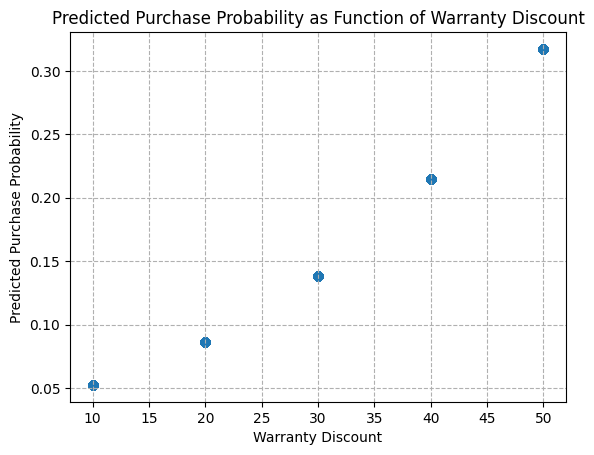

In [12]:
# Calculate and plot predicted probabilities from experiment
Awe_Pred = AWE_logit.predict()
plt.scatter(AWE_Warranty["X"], Awe_Pred)
plt.grid(True,linestyle='--')
plt.title("Predicted Purchase Probability as Function of Warranty Discount")
plt.xlabel("Warranty Discount")
plt.ylabel("Predicted Purchase Probability")

In [13]:
Awe_Pred.mean()

np.float64(0.15900000000000006)

In [14]:
AWE_logit.classification_table()
# Correct predictions: 550+97, incorrect prediction 291+62

[550.0, 291.0, 62.0, 97.0]


,Summary,Actual,Predicted,Frequency
0,Correct,0,0,550.0
1,Incorrect,0,1,291.0
2,Incorrect,1,0,62.0
3,Correct,1,1,97.0


The following estimates a regression of Y versus X. This model assumes that purchase probability increases linearly with the discount. Recall that a regression with a (0,1) dependent variable is called a Linear Probability Model. Hence, I use LPM in the name of the regression to denote the linear probability model.

In [15]:
AWE_LPM=tprstats.model("cs", "Y ~ X", AWE_Warranty)
AWE_LPM.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.064
No. Observations:                1000   F-statistic:                     66.14
Covariance Type:                  HC1   Prob (F-statistic):           1.24e-15
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0358      0.021     -1.698      0.090      -0.077       0.006
X              0.0066      0.001      8.133      0.000       0.005       0.008
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [16]:
# Calculate predicted values from the above linear probability model and name the result PredLPM.
PredLPM=AWE_LPM.predict()

The first command plots the predicted values from the logit model using black dots. The second command plots the results from the linear probability model using red x symbol.

Text(0, 0.5, 'Predicted Purchase Probability')

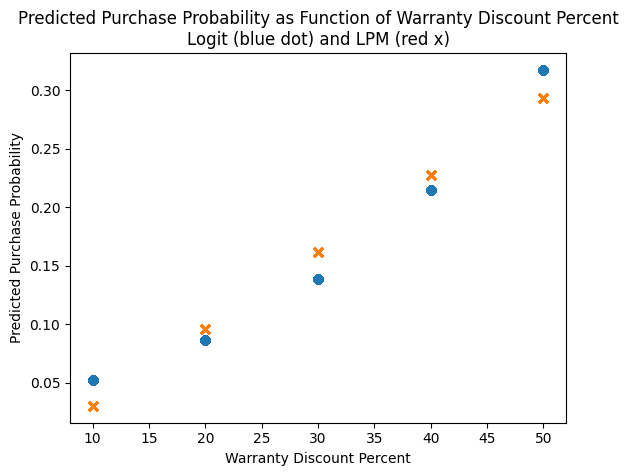

In [17]:
plt.scatter(AWE_Warranty["X"], Awe_Pred,marker='o', linestyle='-' )
plt.scatter(AWE_Warranty["X"], PredLPM,marker='x', linestyle='-')
#plt.scatter(ExpAve['X'],ExpAve['AveBuy'],marker='o', linestyle='-')
plt.title("Predicted Purchase Probability as Function of Warranty Discount Percent\nLogit (blue dot) and LPM (red x)")
plt.xlabel("Warranty Discount Percent")
plt.ylabel("Predicted Purchase Probability")

In the cell that follows, we create an array called Xnew that has integer values from 0 to 50. Profit_Per_Purchase is a vector containing profit obtained for each of the 51 values of Xnew.

In [30]:
# Create discount percent values from 0 to 50, name Discpct and put in a dataframe named Discpct
Discpct=numpy.arange(51)
Discpct = pandas.DataFrame({"X": Discpct})

# Calculate profit per purchase for each value of discount
Profit_Per_Purchase=(300 * (1 - Discpct/100) - 120)

# Predict purchase probabilities for each value of discount using logit model
Purchase_Probs=AWE_logit.predict(Discpct)
# Calculate expected profit for each discount
Profit=Profit_Per_Purchase.T*Purchase_Probs

# Put Purchase_Probs in a dataframe
Purchase_Probs = pandas.DataFrame({"X": Purchase_Probs})

# Calculate warranty price for each discount
Price=300 * (1 - Discpct/ 100)

# Calculate predicted profit
Profit=(Price-120)*Purchase_Probs

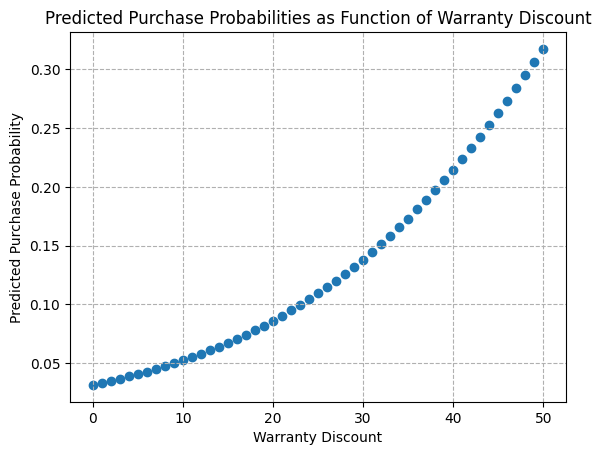

In [31]:
# Create scatter plot of predicted purchase probabilities and label the plot
plt.grid(True,linestyle='--')
plt.title("Predicted Purchase Probabilities as Function of Warranty Discount")
plt.xlabel("Warranty Discount")
plt.ylabel("Predicted Purchase Probability")
plt.scatter(Discpct, Purchase_Probs)

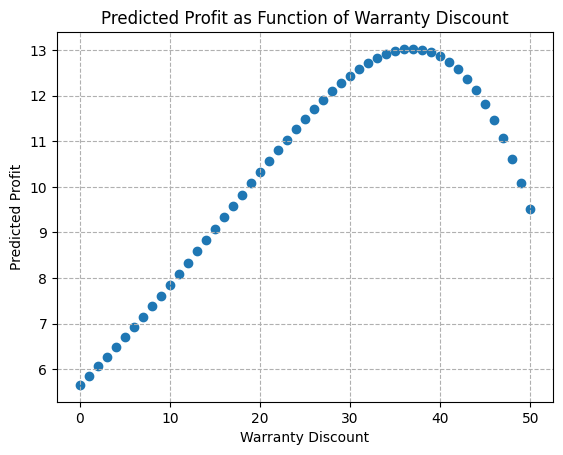

In [32]:
# Create scatter plot of predicted profit vs warranty discount and label the plot
plt.grid(True,linestyle='--')
plt.title("Predicted Profit as Function of Warranty Discount")
plt.xlabel("Warranty Discount")
plt.ylabel("Predicted Profit")
plt.scatter(Discpct, Profit)

The following cell finds the number of rows and columns of Xnew. It reports that Xnew has 51 rows and 1 column.
The subsequent cell finds the number of rows and columns of Xnew. It reports Purchase_Probs has 51 rows and 1 column.

In [ ]:
# Put key variables in a data frame
Key_Variables=pandas.concat([Discpct,Purchase_Probs, Profit,Price], axis=1)
# Name the columns in Key_Variables
Key_Variables.columns=['Discpct','Purchase_Probs','Profit','Price']
# Round all values to 3 digits after decimal point
Key_Variables=Key_Variables.round(3)
# View the results. Scroll down to find discount that maximizes profit
print(Key_Variables)

In [34]:
# find the row number with maximum profit
max_row = Key_Variables['Profit'].idxmax()
# Report the values in the row with maximum profit
MaxProfitRow = Key_Variables.iloc[max_row]
print(MaxProfitRow)
Price=300*(1-38/100)  # To calculate Price, we insert the optimal discount which is 38%
print(Price)
# We find that maximum profit per warranty is obtained with a discount of 38 percent. The purchase probability is .188.
# Expected profit per warranty is $12.40
# Price of warranty at the chosen discount is $186

Discpct            37.000
Purchase_Probs      0.189
Profit             13.024
Price             189.000
Name: 37, dtype: float64
186.0


In [23]:
#If we wish, we can write our results to a csv file.
# I named the file AWE_Results
Key_Variables.to_csv('AWE_Results.csv', index=False)


When doing analysis is Python, it is often useful to be able to find the dimensions of a data frame. The following commands show how to find the number of rows and columns of our Key_Variables data frame.

In [24]:
#Key_Variables=
rows, cols = Key_Variables.shape
print(f"Number of rows: {rows}, Number of columns: {cols}")

Number of rows: 51, Number of columns: 4
